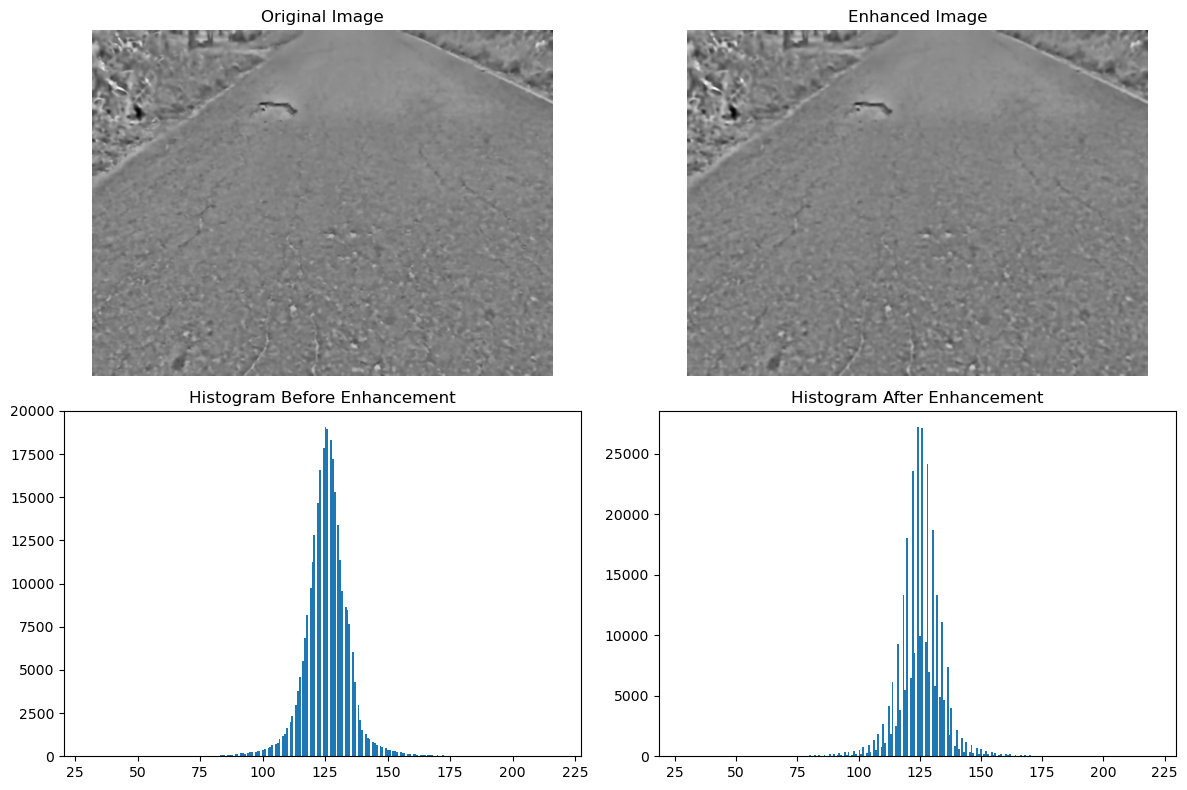

All frames processed


In [3]:
import cv2, os, numpy as np, matplotlib.pyplot as plt

inp = "enhanced_images"
out = "final_output"
os.makedirs(out, exist_ok=True)

prev = None

for f in sorted(os.listdir(inp)):

    img = cv2.imread(os.path.join(inp,f))
    if img is None: continue

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    smooth = cv2.bilateralFilter(gray,5,50,50)

    if cv2.Laplacian(smooth,cv2.CV_64F).var() < 120:
        blur = cv2.GaussianBlur(smooth,(0,0),2)
        smooth = cv2.addWeighted(smooth,1.5,blur,-0.5,0)

    if prev is not None and np.mean(cv2.absdiff(prev,smooth)) > 20:
        smooth = cv2.bilateralFilter(smooth,5,75,75)

    prev = smooth.copy()

    cv2.imwrite(os.path.join(out,f),smooth)

    # Show example with histogram
    if f == "frame_0000.png":

        plt.figure(figsize=(12,8))

        plt.subplot(2,2,1)
        plt.imshow(gray,cmap="gray")
        plt.title("Original Image"); plt.axis("off")

        plt.subplot(2,2,2)
        plt.imshow(smooth,cmap="gray")
        plt.title("Enhanced Image"); plt.axis("off")

        plt.subplot(2,2,3)
        plt.hist(gray.ravel(),bins=256)
        plt.title("Histogram Before Enhancement")

        plt.subplot(2,2,4)
        plt.hist(smooth.ravel(),bins=256)
        plt.title("Histogram After Enhancement")

        plt.tight_layout()
        plt.show()

print("All frames processed")